# Assignment 3 - Building a Simplified Transformer for Sentiment Analysis

This file implement simplified Transformer from scratch to classify the perform sentiment analysis on IMDb dataset..

In [1]:
# import relevant libraries
import torch
from torch.utils.data import DataLoader # to prepare for DataLoader
from datasets import load_dataset

from train_utils import train, test # Shared training/testing function across all notebook file
from transformer_encoder import TransformerEncoder # Shared Transformer encoder architecture across all notebook file
from tokenisation_utils import tokenise_words, build_vocabulary, compute_oov_rate, tokenise_function # Shared frequency-based tokenisation across all notebook file

### 1. Load The IMDb Dataset, Preprocessing, and Dataset Handling

In [2]:
# load the dataset
imdb_dataset = load_dataset('stanfordnlp/imdb')

In [3]:
target_names = ['negative','positive'] # how can I know 0=negative, 1=positive?

#### Build a word-frequency vocabulary

Instead of a pretrained BERT WordPiece tokeniser, this section builds a simple word-level vocabulary directly from the IMDb train corpus: count every word's frequency, then keep only the `custom_vocab_size` most frequent words. This matches the assignment's "simple word embedding layer" requirement more closely than a subword tokeniser. Words outside this vocabulary are mapped to `[UNK]` at tokenisation time.

In [4]:
# build a word-level vocabulary, keeping only the most frequent words
custom_vocab_size = 20000 # change this value to experiment with vocab capacity later

# build the vocabulary from the training corpus only (never the test set, to avoid leakage)
word_to_id = build_vocabulary(imdb_dataset["train"], vocab_size=custom_vocab_size)
pad_token_id = word_to_id["[PAD]"]
unk_token_id = word_to_id["[UNK]"]

print(f"Vocabulary size: {len(word_to_id)}")

Vocabulary size: 20000


In [5]:
train_oov_rate = compute_oov_rate(imdb_dataset["train"], word_to_id)
test_oov_rate = compute_oov_rate(imdb_dataset["test"], word_to_id)

print(f"Train OOV rate: {train_oov_rate:.2%}")
print(f"Test OOV rate: {test_oov_rate:.2%}")

Train OOV rate: 2.29%
Test OOV rate: 2.97%


In [6]:
# define the tokenisation function (manual word-to-id mapping, no HuggingFace tokeniser)
max_seq_length = 600

In [ ]:
# tokenise the dataset
tokenised_datasets = imdb_dataset.map( # map is used to apply a processing transformation
    lambda examples: tokenise_function(examples, word_to_id, unk_token_id, pad_token_id, max_seq_length),
    batched=True
)
# run the tokenise_function in batch. Tokenise text into words, maps each word to an id with word_to_id
# truncates/pads every sequence to max_seq_length


tokenised_datasets = tokenised_datasets.select_columns(["input_ids", "attention_mask", "label"])
# select.columns is used to drop everything excep the three columns that needed.

tokenised_datasets.set_format("torch") # return PyTorch tensors for further task

In [8]:
# create PyToch DataLoaders
train_dataloader = DataLoader(
    tokenised_datasets["train"],
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    tokenised_datasets["test"],
    batch_size=32,
    shuffle=False
)

93

In [9]:
# show information of the datasets per batch
for batch in train_dataloader:
    print("Input IDs shape:", batch["input_ids"].shape)          # [32, 512]
    print("Attention Mask shape:", batch["attention_mask"].shape)  # [32, 512]
    print("Labels shape:", batch["label"].shape)                 # [32]
    break

Input IDs shape: torch.Size([32, 600])
Attention Mask shape: torch.Size([32, 600])
Labels shape: torch.Size([32])


### 2. Transformers Implementation

**1. Architecture Requirements**
- **Input Embedding Layer**:
    - Convert input text to token embeddings using a simple word embedding layer.
    - Use torch.nn.Embedding or implement your own.
- **Positional Encoding**:
    - Add positional encodings to input embeddings to incorporate sequential information.
- **Self-Attention Mechanism**:
    - Implement scaled dot-product attention: $$\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V$$
    - Use multi-head attention for richer feature representations.
- **Feedforward Network**:
    - Add a two-layer feedforward network with ReLU activation.
- **Classification Head**:
    - Use a fully connected layer to map the output of the Transformer to a binary label (positive or negative).
- **Architecture Summary**:
    - Input → Embedding → Positional Encoding → Multi-Head Attention → Feedforward → Classification Head → Output

**2. Forward Propagation**
- Implement tokenization, embedding, attention computation, and feedforward operations.
- Use softmax activation in the output layer for binary classification probabilities.

**3. Backward Propagation**
- Compute gradients for all weights using binary cross-entropy loss.
- Update weights using **Adam Optimizer**.

**4. Training Loop**
- Train the Transformer for **10** epochs with:
    - Batch size: **32**
    - Learning rate: **0.001**
- Use mini-batch processing.

**5. Evaluation**
- Evaluate the model on the IMDb test set.
- Calculate and report **accuracy, precision, recall, and F1-score**.

The encoder block of Transformers consist of (in order):
- Multi-head attention
- Residual connection and layer normalisation
- Fully connected feed-forward network
- Residual connection and layer normalisation


### 3. Training Phase

In [10]:
# detect the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [11]:
# instantiate the model
encoder = TransformerEncoder(
    num_layers=4, # number of encoder block
    d_model=64, # width of every token vector representation
    num_heads=4, # head dim is d_model / num_heads
    d_ff=256, # width of feed forward hidden layer
    input_vocab_size=len(word_to_id),
    max_seq_length=600,
    pad_token_id=pad_token_id,
    dropout=0 # no dropout
    )
encoder = encoder.to(device)

In [12]:
encoder

TransformerEncoder(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (enc_layers): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=64, out_features=64, bias=True)
        (wk): Linear(in_features=64, out_features=64, bias=True)
        (wv): Linear(in_features=64, out_features=64, bias=True)
        (dense): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
  )
  (classification): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0, inplace=False)
)

In [23]:
optimiser = torch.optim.Adam(encoder.parameters(), lr=0.001)
criterion = torch.nn.BCELoss()

Performing the training phase..
Epoch: 1/10 | Train Loss: 0.4651 | Val Loss: 0.3325
Epoch: 2/10 | Train Loss: 0.3384 | Val Loss: 0.2649
Epoch: 3/10 | Train Loss: 0.2879 | Val Loss: 0.2541
Epoch: 4/10 | Train Loss: 0.2475 | Val Loss: 0.2001
Epoch: 5/10 | Train Loss: 0.2185 | Val Loss: 0.1702
Epoch: 6/10 | Train Loss: 0.1910 | Val Loss: 0.1390
Epoch: 7/10 | Train Loss: 0.1693 | Val Loss: 0.1448
Epoch: 8/10 | Train Loss: 0.1492 | Val Loss: 0.1151
Epoch: 9/10 | Train Loss: 0.1308 | Val Loss: 0.0927
Epoch: 10/10 | Train Loss: 0.1165 | Val Loss: 0.0855
The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.97      0.98      0.97     12500
    positive       0.98      0.97      0.97     12500

    accuracy                           0.97     25000
   macro avg       0.97      0.97      0.97     25000
weighted avg       0.97      0.97      0.97     25000

The confusion matrix is:
----

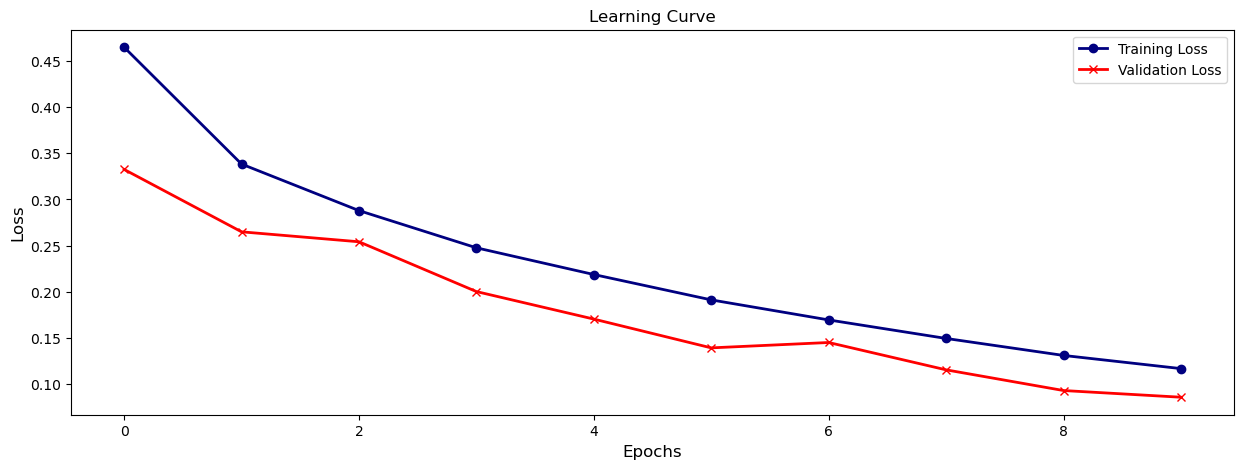

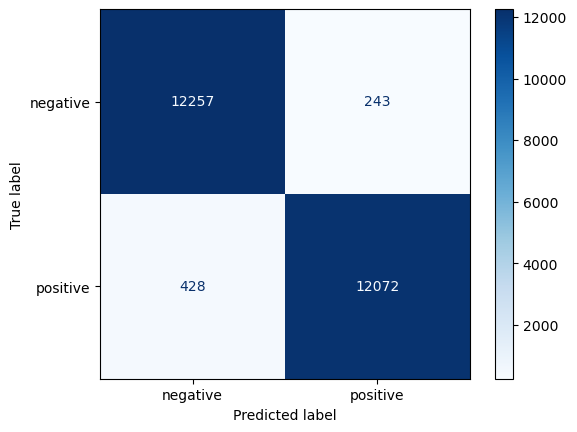


The training is completed!

Elapsed training time is: 1246.6217076778412 seconds (20.78 minutes)


In [24]:
# Call the training function
result = train(encoder, train_loader=train_dataloader, optimiser=optimiser, criterion=criterion, target_names=target_names, device=device, epochs=10)

The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.83      0.87      0.85     12500
    positive       0.86      0.82      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000


The confusion matrix is:
------------------------------------------------------------
[[10830  1670]
 [ 2236 10264]]


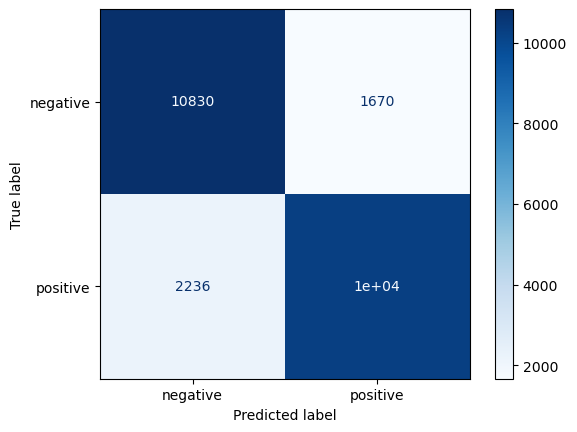


The testing is completed!


In [25]:
result = test(encoder, test_loader=test_dataloader, target_names=target_names, device=device, result_dict=result)

In [26]:
result['test']

{'negative': {'precision': 0.8288688198377469,
  'recall': 0.8664,
  'f1-score': 0.8472189626848158,
  'support': 12500.0},
 'positive': {'precision': 0.8600636835930954,
  'recall': 0.82112,
  'f1-score': 0.8401407874273553,
  'support': 12500.0},
 'accuracy': 0.84376,
 'macro avg': {'precision': 0.8444662517154211,
  'recall': 0.84376,
  'f1-score': 0.8436798750560855,
  'support': 25000.0},
 'weighted avg': {'precision': 0.8444662517154211,
  'recall': 0.84376,
  'f1-score': 0.8436798750560855,
  'support': 25000.0}}